# ChatKHU 크레딧 사용 진단 분석
**기간**: 2026-03-01 ~ 2026-06-15  
**목적**: 크레딧 사용 전체 분포 파악 → 세그먼트별 다면 진단  
**데이터**: `*_deidentified` 파일만 사용


## 0. Setup & 데이터 로딩

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib          # 한글 폰트 (NanumGothic)

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')
print("✓ Setup complete")


In [2]:
DATA_DIR = '../data'

df = pd.read_csv(
    f'{DATA_DIR}/member_deidentified/member_export_2026-03-01_to_2026-06-15_004713.csv',
    low_memory=False
)
df['최초 가입일'] = pd.to_datetime(df['최초 가입일'], errors='coerce')
df['가입 승인']  = pd.to_datetime(df['가입 승인'],  errors='coerce')

print(f"멤버 데이터: {df.shape[0]:,}명 × {df.shape[1]}컬럼")
print(f"가입일 범위: {df['최초 가입일'].min().date()} ~ {df['최초 가입일'].max().date()}")
print(f"신분 분포:   {df['신분'].value_counts().to_dict()}")
print(f"크레딧 범위: 0 ~ {df['기간 내 크레딧 사용량 총합'].max():,.0f}")


멤버 데이터: 8,249명 × 422컬럼
가입일 범위: 2025-05-13 ~ 2026-06-15
신분 분포:   {'학생': 6859, '교수': 729, '교직원': 648, '정보처운영지원': 7, '학생, 학생': 2, '법인사용자': 2}
크레딧 범위: 0 ~ 415,588


In [3]:
# 모델별 크레딧 컬럼 추출 헬퍼
def get_models(df):
    models, seen = [], set()
    for c in df.columns:
        for sfx in [' Input 크레딧', ' Output 크레딧', ' 웹검색 크레딧']:
            if c.endswith(sfx):
                name = c[: -len(sfx)]
                # .1/.2 중복 제거, None 제외
                if name.startswith('None') or '.' in name.split(' ')[-1]:
                    break
                if name not in seen:
                    seen.add(name)
                    models.append(name)
                break
    return models

MODELS = get_models(df)

def model_credit_sum(df_sub, model):
    cols = [c for c in df_sub.columns
            if (c.startswith(model + ' ') and
                any(c.endswith(s) for s in [' Input 크레딧', ' Output 크레딧', ' 웹검색 크레딧']) and
                not c.split()[-1].replace('.','').isdigit())]
    return df_sub[cols].fillna(0).sum(axis=1)

print(f"감지된 모델 수: {len(MODELS)}개")
print("상위 10:", MODELS[:10])


감지된 모델 수: 44개
상위 10: ['Super Agent', 'Gemini 2.5 Flash', 'GPT-5.3 Chat', 'ChatGPT-Auto', 'GPT-5.4 Pro', 'GPT-5.2 Pro', 'GPT-5.4 mini', 'GPT-5.4 nano', 'GPT-5.2 Chat', 'GPT-5.1 Chat']


## 1. 크레딧 사용량 전체 분포 분석

**핵심 질문**: 평균(≈3,083)이 대표값인가?  
평균 >> 중앙값이면 소수 heavy user가 평균을 왜곡 → 운영 전략은 중앙값 기준으로 설계해야 함.


In [4]:
credit  = df['기간 내 크레딧 사용량 총합'].fillna(0)
active  = credit[credit > 0]

def stats_row(s, label):
    return {
        '구분':    label,
        'N':       f"{len(s):,}",
        '평균':    f"{s.mean():,.1f}",
        '중앙값':  f"{s.median():,.1f}",
        '최빈값':  f"{s.mode().iloc[0]:,.1f}" if len(s) else '-',
        '최솟값':  f"{s.min():,.1f}",
        '최댓값':  f"{s.max():,.0f}",
        '표준편차':f"{s.std():,.1f}",
        'P10':     f"{s.quantile(.10):,.1f}",
        'P25':     f"{s.quantile(.25):,.1f}",
        'P75':     f"{s.quantile(.75):,.1f}",
        'P90':     f"{s.quantile(.90):,.1f}",
        'P95':     f"{s.quantile(.95):,.1f}",
        'P99':     f"{s.quantile(.99):,.1f}",
    }

stats_df = pd.DataFrame([
    stats_row(credit, f'전체 유저 (N={len(credit):,})'),
    stats_row(active, f'활성 유저 크레딧>0 (N={len(active):,})'),
]).set_index('구분').T
print(stats_df.to_string())
print(f"\n미사용 유저: {(credit==0).sum():,}명 ({(credit==0).mean()*100:.1f}%)")


구분   전체 유저 (N=8,249) 활성 유저 크레딧>0 (N=6,779)
N              8,249                 6,779
평균           3,083.5               3,752.2
중앙값          1,251.9               1,962.4
최빈값              0.0               2,000.0
최솟값              0.0                   1.2
최댓값          415,588               415,588
표준편차         8,539.4               9,285.8
P10              0.0                  52.9
P25             44.2                 381.5
P75          3,540.7               4,156.6
P90          6,826.8               7,945.0
P95         10,749.1              12,410.2
P99         27,249.5              29,638.2

미사용 유저: 1,470명 (17.8%)


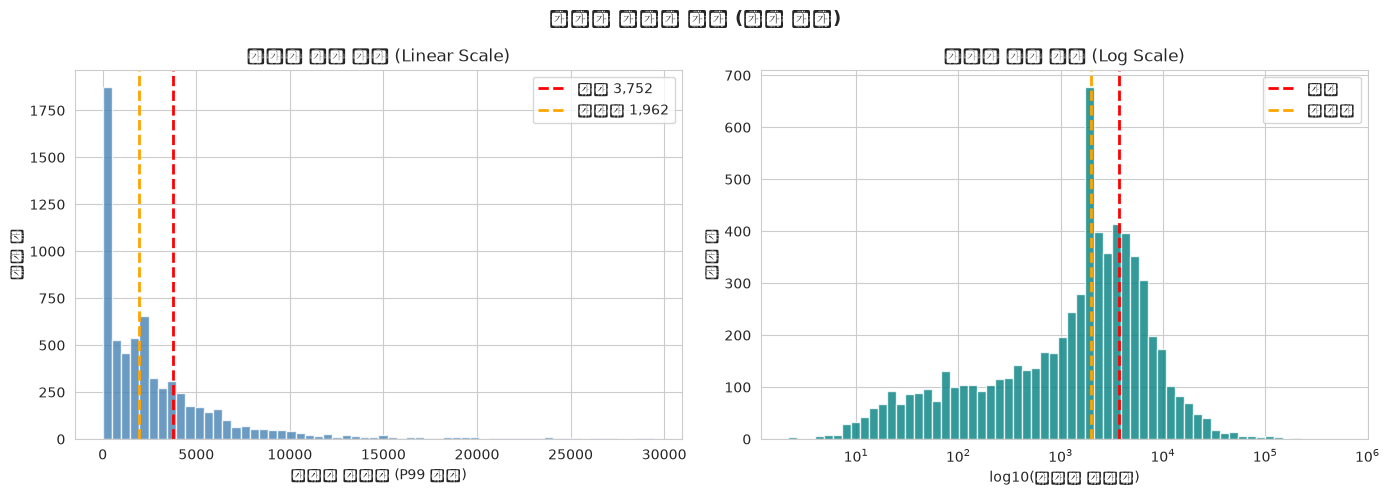

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: linear (P99 이하)
ax = axes[0]
p99 = active.quantile(.99)
ax.hist(active[active <= p99], bins=60, color='steelblue', edgecolor='white', alpha=.8)
ax.axvline(active.mean(),   color='red',    ls='--', lw=2, label=f'평균 {active.mean():,.0f}')
ax.axvline(active.median(), color='orange', ls='--', lw=2, label=f'중앙값 {active.median():,.0f}')
ax.set_xlabel('크레딧 사용량 (P99 이하)')
ax.set_ylabel('유저 수')
ax.set_title('크레딧 사용 분포 (Linear Scale)')
ax.legend()

# 오른쪽: log
ax = axes[1]
log_v = np.log10(active + 1)
ax.hist(log_v, bins=60, color='teal', edgecolor='white', alpha=.8)
ax.axvline(np.log10(active.mean()),   color='red',    ls='--', lw=2, label='평균')
ax.axvline(np.log10(active.median()), color='orange', ls='--', lw=2, label='중앙값')
ticks = [1, 2, 3, 4, 5, 6]
ax.set_xticks(ticks)
ax.set_xticklabels([f'$10^{{{t}}}$' for t in ticks])
ax.set_xlabel('log10(크레딧 사용량)')
ax.set_ylabel('유저 수')
ax.set_title('크레딧 사용 분포 (Log Scale)')
ax.legend()

plt.suptitle('크레딧 사용량 분포 (활성 유저)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('01_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# 구간별 유저 수 & 크레딧 점유율
bins   = [-1, 0, 100, 1_000, 10_000, float('inf')]
labels = ['0 (미사용)', '1~100', '100~1,000', '1,000~10,000', '10,000+']
bkt    = pd.cut(credit, bins=bins, labels=labels, right=False)

bucket = pd.DataFrame({
    '유저 수':       bkt.value_counts().sort_index(),
    '유저 비율(%)':  (bkt.value_counts().sort_index() / len(credit) * 100).round(1),
    '크레딧 합계':   credit.groupby(bkt).sum().sort_index().round(0),
    '크레딧 비율(%)': (credit.groupby(bkt).sum().sort_index() / credit.sum() * 100).round(1),
})
print(bucket.to_string())

print("\n[Pareto 분석] 상위 N% 유저의 크레딧 점유율:")
sorted_c = credit.sort_values(ascending=False).reset_index(drop=True)
cum = sorted_c.cumsum() / credit.sum() * 100
for pct in [1, 5, 10, 20]:
    n = max(1, int(len(sorted_c) * pct / 100))
    print(f"  상위 {pct:2d}% ({n:,}명) → {cum.iloc[n-1]:.1f}% 소비")


                 유저 수  유저 비율(%)      크레딧 합계  크레딧 비율(%)
기간 내 크레딧 사용량 총합                                       
0 (미사용)             0       0.0         NaN        NaN
1~100            2459      29.8     40732.0        0.2
100~1,000        1427      17.3    625039.0        2.5
1,000~10,000     3900      47.3  13950269.0       54.8
10,000+           463       5.6  10819837.0       42.5

[Pareto 분석] 상위 N% 유저의 크레딧 점유율:
  상위  1% (82명) → 19.1% 소비
  상위  5% (412명) → 40.5% 소비
  상위 10% (824명) → 54.3% 소비
  상위 20% (1,649명) → 71.9% 소비


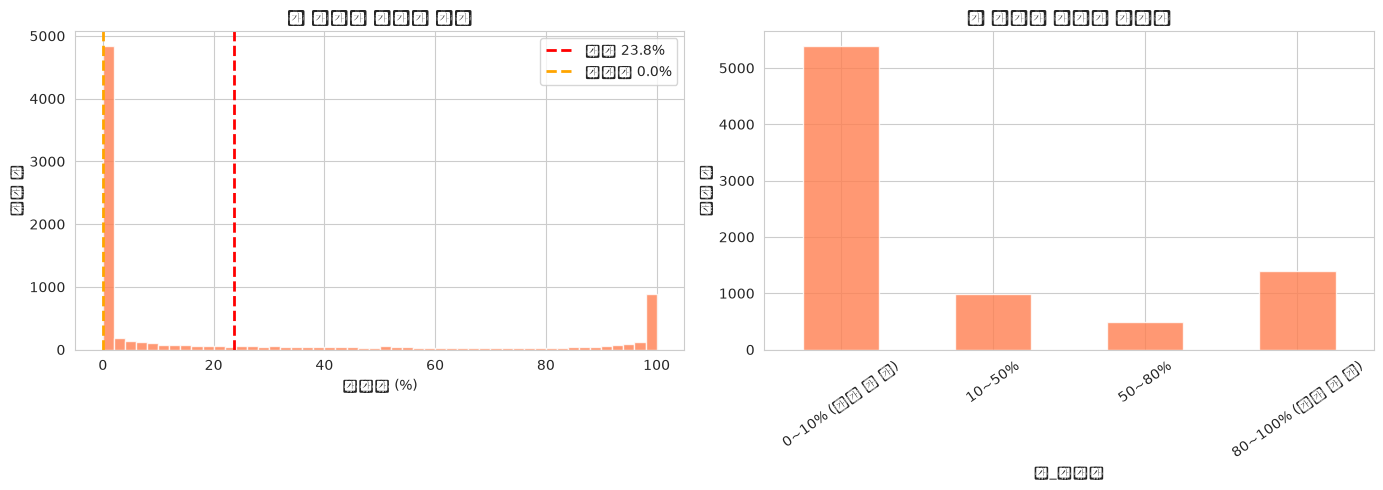

  0~10% (거의 안 씀): 5,381명 (65.2%)
  10~50%: 984명 (11.9%)
  50~80%: 488명 (5.9%)
  80~100% (거의 다 씀): 1,397명 (16.9%)


In [7]:
# 월 크레딧 소진율
df['월_소진율'] = np.where(
    df['현재 월 크레딧 할당량'] > 0,
    (1 - df['현재 월 크레딧 잔여량'].fillna(0) / df['현재 월 크레딧 할당량']) * 100,
    np.nan
)
burn = df['월_소진율'].dropna().clip(0, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(burn, bins=50, color='coral', edgecolor='white', alpha=.8)
ax.axvline(burn.mean(),   color='red',    ls='--', lw=2, label=f'평균 {burn.mean():.1f}%')
ax.axvline(burn.median(), color='orange', ls='--', lw=2, label=f'중앙값 {burn.median():.1f}%')
ax.set_xlabel('소진율 (%)')
ax.set_ylabel('유저 수')
ax.set_title('월 크레딧 소진율 분포')
ax.legend()

burn_labels = ['0~10% (거의 안 씀)', '10~50%', '50~80%', '80~100% (거의 다 씀)']
burn_bkt = pd.cut(burn, bins=[0, 10, 50, 80, 100], labels=burn_labels, include_lowest=True)
burn_bkt.value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color='coral', edgecolor='white', alpha=.8)
axes[1].set_title('월 크레딧 소진율 구간별')
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylabel('유저 수')

plt.tight_layout()
plt.savefig('01b_burn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

for lb, ub, lbl in zip([0,10,50,80], [10,50,80,100], burn_labels):
    n = ((burn >= lb) & (burn <= ub)).sum()
    print(f"  {lbl}: {n:,}명 ({n/len(burn)*100:.1f}%)")


## 2. 크레딧 사용 시계열 추이

In [8]:
from io import StringIO

with open(f'{DATA_DIR}/usage_data_deidentified/'
          'dashboard_2026-03-01_2026-05-31_20260616_063029.csv', 'r') as f:
    lines = f.readlines()

# 섹션 구분
section_idx = [i for i, l in enumerate(lines) if l.strip().startswith('[')]
section_idx.append(len(lines))

def read_section(lines, start, end):
    data = [l for l in lines[start+2:end] if l.strip() and not l.startswith('[')]
    return ''.join(data)

dau_raw   = read_section(lines, section_idx[0], section_idx[1])
model_raw = read_section(lines, section_idx[1], section_idx[2] if len(section_idx) > 2 else len(lines))

dau_df   = pd.read_csv(StringIO(dau_raw),   names=['날짜','DAU','방문자수'])
model_df = pd.read_csv(StringIO(model_raw), names=['날짜','요청수','토큰수','생성수','크레딧','TTFT','완료시간'])
dau_df['날짜']   = pd.to_datetime(dau_df['날짜'],   errors='coerce')
model_df['날짜'] = pd.to_datetime(model_df['날짜'], errors='coerce')
dau_df   = dau_df.dropna(subset=['날짜'])
model_df = model_df.dropna(subset=['날짜'])
# pandas 3.x StringDtype → numeric 변환
for col in ['DAU','방문자수']:
    dau_df[col] = pd.to_numeric(dau_df[col], errors='coerce')
for col in ['요청수','토큰수','생성수','크레딧','TTFT','완료시간']:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

print(f"DAU 데이터:     {len(dau_df)}일")
print(f"일 평균 DAU:    {dau_df['DAU'].mean():.0f}")
print(f"최대 DAU:       {dau_df['DAU'].max()} ({dau_df.loc[dau_df['DAU'].idxmax(),'날짜'].date()})")
print(f"총 크레딧(기간): {model_df['크레딧'].sum():,.0f}")


DAU 데이터:     92일
일 평균 DAU:    206
최대 DAU:       686.0 (2026-05-11)
총 크레딧(기간): 18,838,599


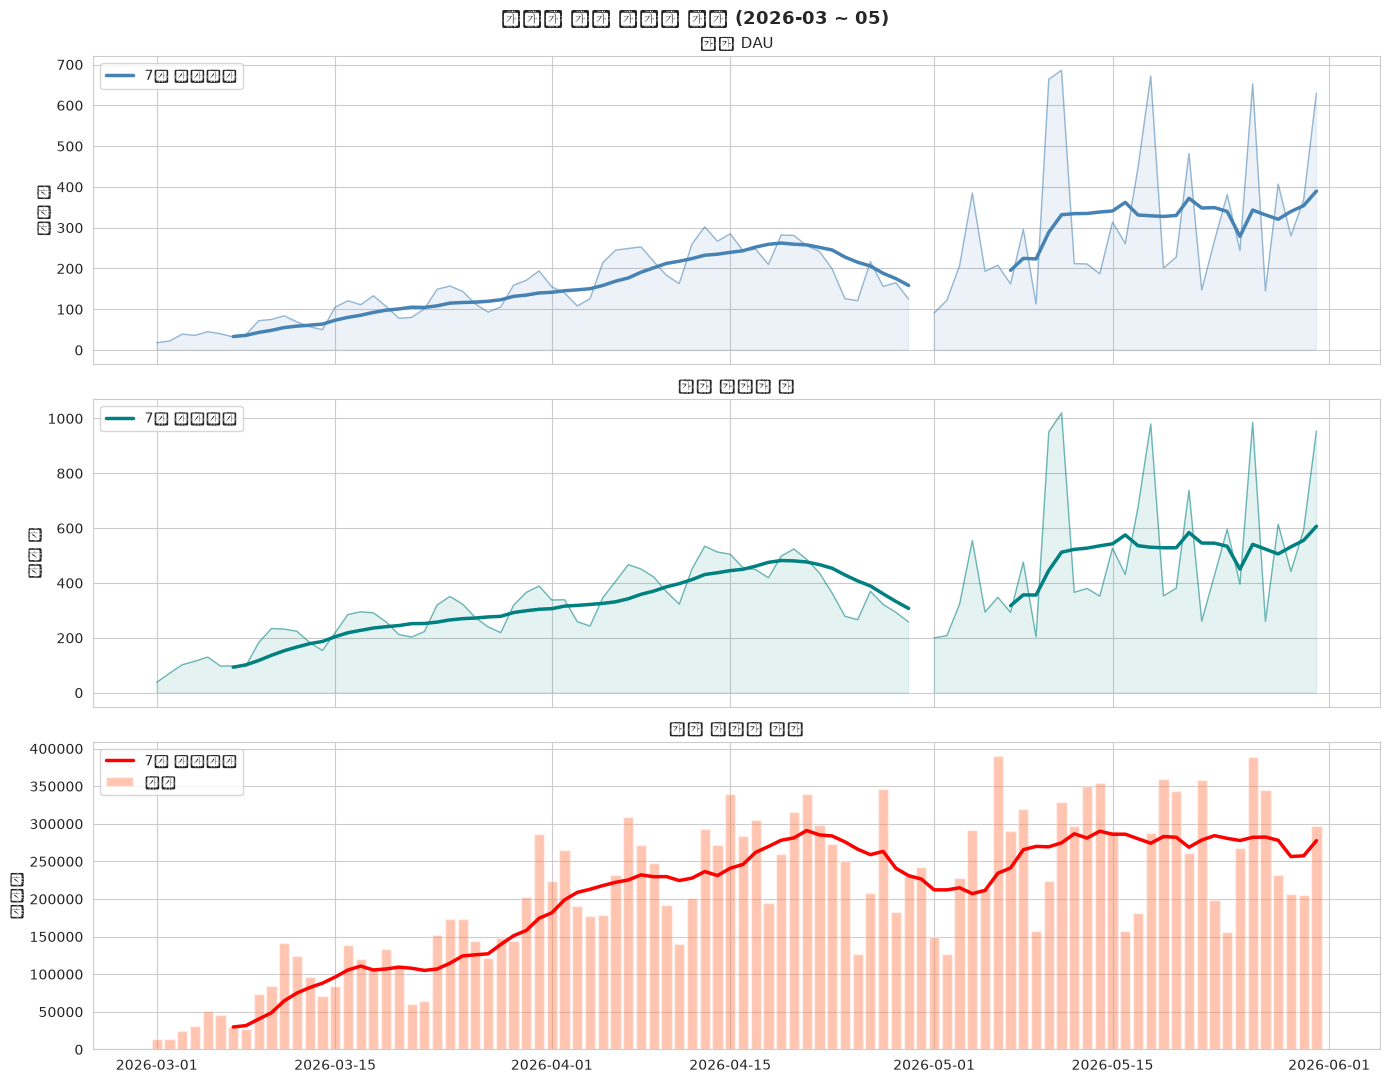

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

for ax, col, label, color in [
    (axes[0], 'DAU',    '일별 DAU',          'steelblue'),
    (axes[1], '방문자수', '일별 방문자 수',    'teal'),
]:
    ax.plot(dau_df['날짜'], dau_df[col], color=color, lw=1, alpha=.5)
    ax.plot(dau_df['날짜'], dau_df[col].rolling(7).mean(), color=color, lw=2.5, label='7일 이동평균')
    ax.fill_between(dau_df['날짜'], dau_df[col], alpha=.1, color=color)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('유저 수')
    ax.legend()

axes[2].bar(model_df['날짜'], model_df['크레딧'], color='coral', alpha=.45, label='일별')
axes[2].plot(model_df['날짜'], model_df['크레딧'].rolling(7).mean(),
             color='red', lw=2.5, label='7일 이동평균')
axes[2].set_title('일별 크레딧 소비', fontsize=11)
axes[2].set_ylabel('크레딧')
axes[2].legend()

plt.suptitle('서비스 사용 시계열 추이 (2026-03 ~ 05)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


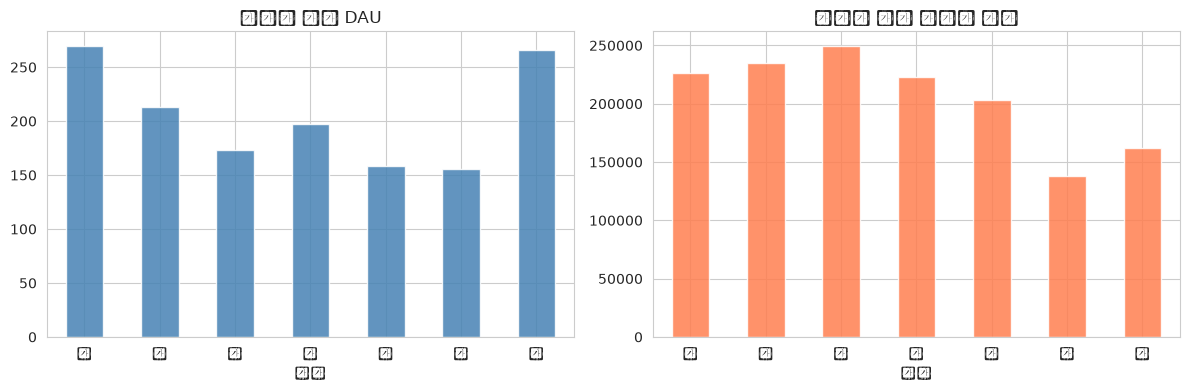

In [10]:
day_names = ['월','화','수','목','금','토','일']
dau_df['요일']   = dau_df['날짜'].dt.dayofweek
model_df['요일'] = model_df['날짜'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dau_df.groupby('요일')['DAU'].mean().rename(index=dict(enumerate(day_names))).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white', alpha=.85)
axes[0].set_title('요일별 평균 DAU')
axes[0].tick_params(axis='x', rotation=0)

model_df.groupby('요일')['크레딧'].mean().rename(index=dict(enumerate(day_names))).plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white', alpha=.85)
axes[1].set_title('요일별 평균 크레딧 소비')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('02b_weekday.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. 가입일 기준 코호트 분석

In [11]:
def cohort_group(ym):
    if pd.isna(ym): return '기타'
    s = str(ym)
    if s < '2025-01': return '2025년 이전'
    if s < '2026-01': return '2025년'
    return s   # '2026-03' 등

df['가입월']  = df['최초 가입일'].dt.to_period('M').astype(str)
df['코호트']  = df['가입월'].apply(cohort_group)
cohort_order = [c for c in ['2025년 이전','2025년',
                             '2026-01','2026-02','2026-03','2026-04','2026-05','2026-06','기타']
                if c in df['코호트'].unique()]

CREDIT = '기간 내 크레딧 사용량 총합'
cohort_df = df.groupby('코호트')[CREDIT].agg(
    유저수='count',
    활성유저수=lambda x: (x > 0).sum(),
    평균크레딧='mean',
    중앙값크레딧='median',
    총크레딧='sum',
).reindex(cohort_order)
cohort_df['활성화율(%)'] = (cohort_df['활성유저수'] / cohort_df['유저수'] * 100).round(1)
print(cohort_df.round(0).to_string())


          유저수  활성유저수   평균크레딧  중앙값크레딧        총크레딧  활성화율(%)
코호트                                                      
2025년     253    168  9167.0   780.0   2319274.0     66.0
2026-01    43     26  9084.0  3500.0    390618.0     60.0
2026-02   287    195  3818.0   840.0   1095658.0     68.0
2026-03  3410   2833  3758.0  1745.0  12813780.0     83.0
2026-04  2032   1758  2715.0  1624.0   5516663.0     86.0
2026-05  1489   1220  1696.0   864.0   2525674.0     82.0
2026-06   735    579  1053.0   369.0    774209.0     79.0


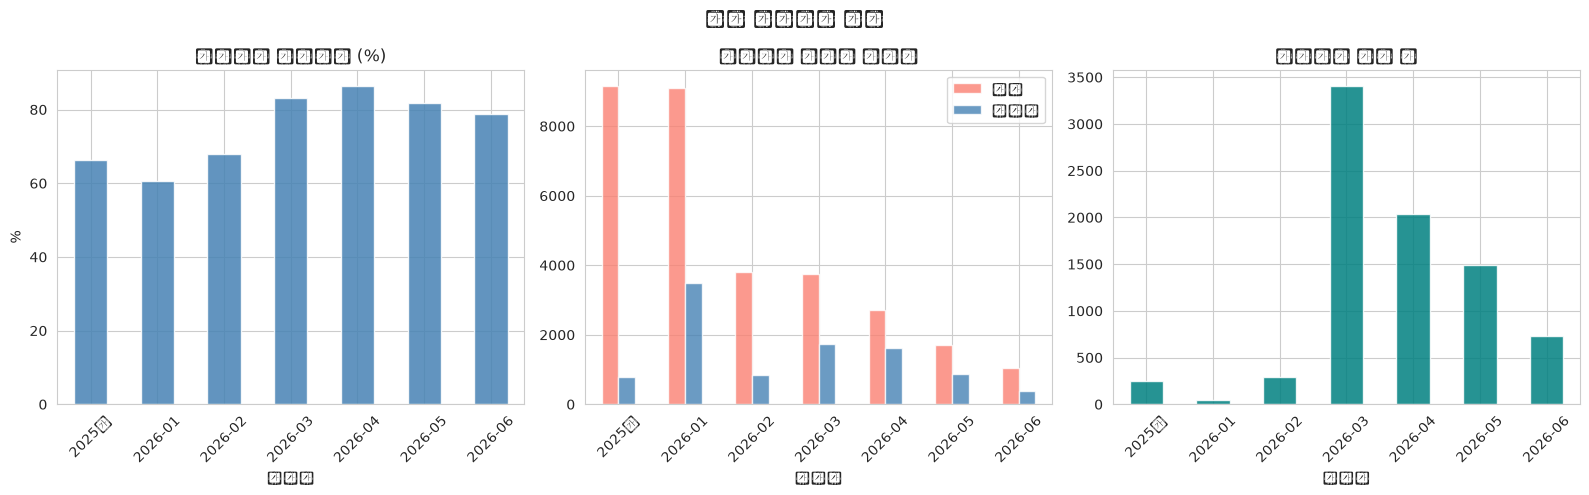

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cohort_df['활성화율(%)'].plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white', alpha=.85)
axes[0].set_title('코호트별 활성화율 (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('%')

cohort_df[['평균크레딧','중앙값크레딧']].plot(kind='bar', ax=axes[1],
    color=['salmon','steelblue'], edgecolor='white', alpha=.8)
axes[1].set_title('코호트별 크레딧 사용량')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['평균','중앙값'])

cohort_df['유저수'].plot(kind='bar', ax=axes[2],
    color='teal', edgecolor='white', alpha=.85)
axes[2].set_title('코호트별 유저 수')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('가입 코호트별 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_cohort.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. 세그먼트별 분석

### 4-1. 신분별

In [13]:
df['신분_정제'] = df['신분'].str.split(',').str[0].str.strip()
df_m = df[df['신분_정제'].isin(['학생','교수','교직원'])].copy()

seg = df_m.groupby('신분_정제')[CREDIT].agg(
    유저수='count',
    활성유저수=lambda x: (x > 0).sum(),
    평균='mean', 중앙값='median',
    P90=lambda x: x.quantile(.9),
    최대='max', 총합='sum',
)
seg['활성화율(%)']  = (seg['활성유저수'] / seg['유저수'] * 100).round(1)
seg['총합_비중(%)'] = (seg['총합'] / seg['총합'].sum() * 100).round(1)
print(seg.round(1).to_string())


        유저수  활성유저수      평균     중앙값      P90        최대          총합  활성화율(%)  총합_비중(%)
신분_정제                                                                               
교수      729    622  5827.7  1654.8  13541.7  415588.0   4248389.0     85.3      16.7
교직원     648    496  5082.7   660.2  11512.9  188721.9   3293579.3     76.5      13.0
학생     6861   5654  2605.5  1278.9   5962.7  128173.6  17876426.0     82.4      70.3


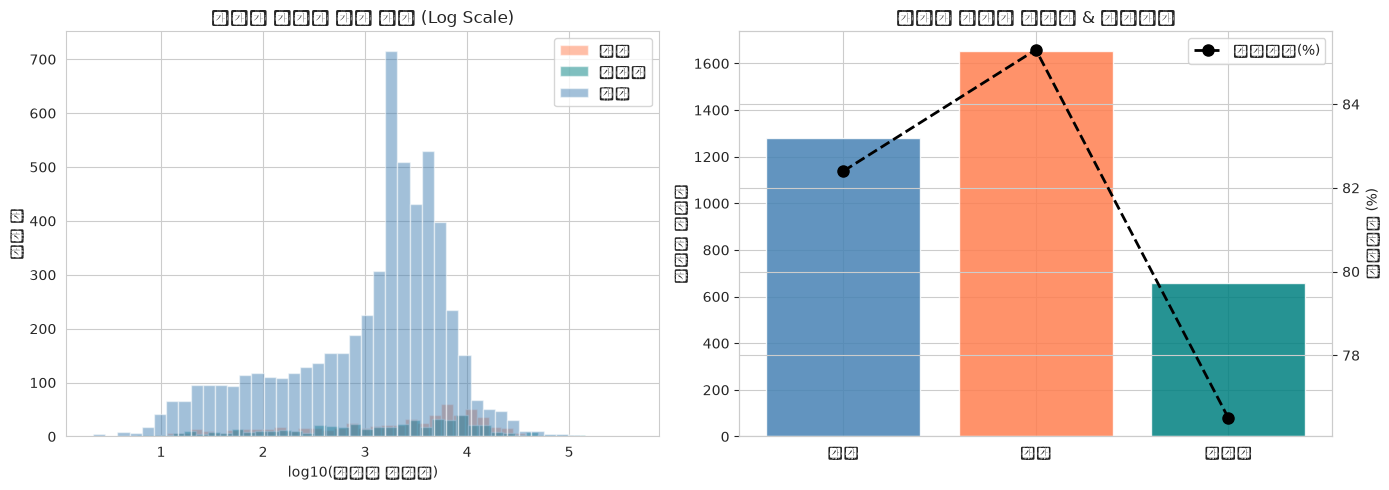

In [14]:
PAL = {'학생':'steelblue','교수':'coral','교직원':'teal'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for 신분, grp in df_m[df_m[CREDIT] > 0].groupby('신분_정제'):
    ax.hist(np.log10(grp[CREDIT]+1), bins=40, alpha=.5,
            label=신분, color=PAL.get(신분,'gray'))
ax.set_xlabel('log10(크레딧 사용량)')
ax.set_ylabel('유저 수')
ax.set_title('신분별 크레딧 사용 분포 (Log Scale)')
ax.legend()

ax2 = axes[1]
ids = ['학생','교수','교직원']
vals = [seg.loc[s,'중앙값'] if s in seg.index else 0 for s in ids]
bars = ax2.bar(ids, vals, color=[PAL[s] for s in ids], edgecolor='white', alpha=.85)
ax2t = ax2.twinx()
actv = [seg.loc[s,'활성화율(%)'] if s in seg.index else 0 for s in ids]
ax2t.plot(ids, actv, 'o--', color='black', lw=2, ms=8, label='활성화율(%)')
ax2t.set_ylabel('활성화율 (%)')
ax2.set_ylabel('크레딧 중앙값')
ax2.set_title('신분별 크레딧 중앙값 & 활성화율')
ax2t.legend(loc='upper right')

plt.tight_layout()
plt.savefig('04a_identity.png', dpi=150, bbox_inches='tight')
plt.show()


### 4-2. 소속별

In [15]:
dept = df_m.groupby('소속')[CREDIT].agg(
    유저수='count',
    활성유저수=lambda x: (x > 0).sum(),
    총크레딧='sum', 중앙값크레딧='median', 평균크레딧='mean',
).sort_values('총크레딧', ascending=False)
dept['활성화율(%)'] = (dept['활성유저수'] / dept['유저수'] * 100).round(1)
print("=== 총 크레딧 상위 20개 소속 ===")
print(dept.head(20).round(0).to_string())


=== 총 크레딧 상위 20개 소속 ===
                 유저수  활성유저수      총크레딧  중앙값크레딧   평균크레딧  활성화율(%)
소속                                                            
경영학과             323    253  848528.0  1346.0  2627.0     78.0
소프트웨어융합학과        165    123  829824.0  1308.0  5029.0     74.0
컴퓨터공학부           277    222  700696.0   872.0  2530.0     80.0
국제학과             155    138  593903.0  1989.0  3832.0     89.0
기계공학부            178    157  581456.0  1563.0  3267.0     88.0
정보디스플레이학과        126    109  575994.0  2927.0  4571.0     86.0
전자공학부            136    116  525871.0  1583.0  3867.0     85.0
Hospitality경영학과  132    106  519580.0  2123.0  3936.0     80.0
의학과              124     97  505685.0  1694.0  4078.0     78.0
미디어학과            167    131  495365.0  1330.0  2966.0     78.0
경영회계계열           158    139  437804.0  1741.0  2771.0     88.0
행정학과             104     97  395969.0  2052.0  3807.0     93.0
화학과              136    114  391748.0  1174.0  2881.0     84.0
전자공학과            177    138  38

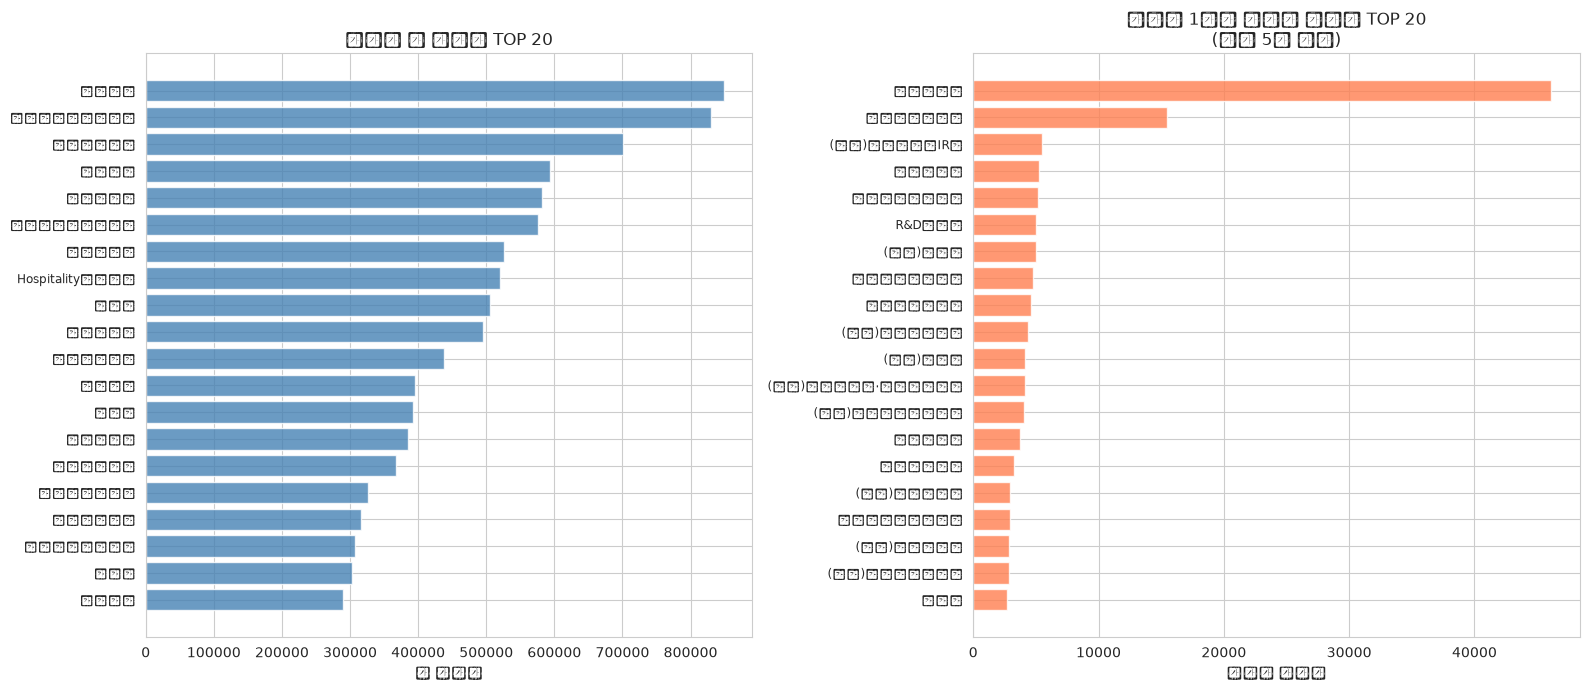

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top20t = dept.head(20)
axes[0].barh(range(len(top20t)), top20t['총크레딧'], color='steelblue', alpha=.8)
axes[0].set_yticks(range(len(top20t)))
axes[0].set_yticklabels(top20t.index, fontsize=8.5)
axes[0].invert_yaxis()
axes[0].set_xlabel('총 크레딧')
axes[0].set_title('소속별 총 크레딧 TOP 20')

top20m = dept[dept['유저수'] >= 5].nlargest(20, '중앙값크레딧')
axes[1].barh(range(len(top20m)), top20m['중앙값크레딧'], color='coral', alpha=.8)
axes[1].set_yticks(range(len(top20m)))
axes[1].set_yticklabels(top20m.index, fontsize=8.5)
axes[1].invert_yaxis()
axes[1].set_xlabel('크레딧 중앙값')
axes[1].set_title('소속별 1인당 크레딧 중앙값 TOP 20\n(최소 5명 이상)')

plt.tight_layout()
plt.savefig('04b_dept.png', dpi=150, bbox_inches='tight')
plt.show()


### 4-3. 직급/과정별 (학생)

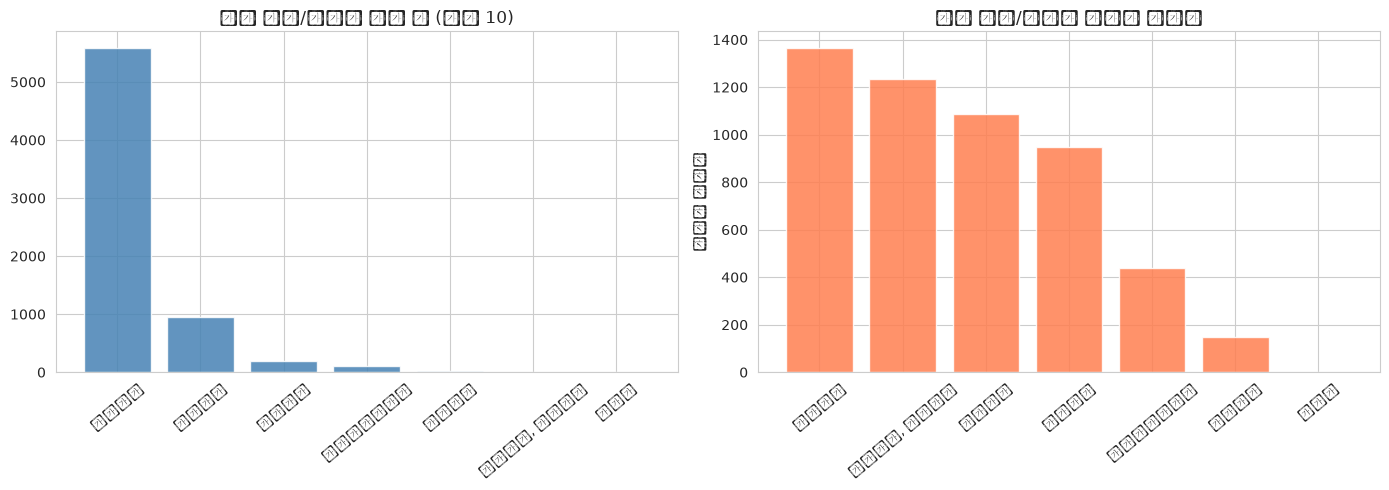

In [17]:
students = df_m[df_m['신분_정제'] == '학생'].copy()
students['직급_정제'] = students['직급/과정'].fillna('미입력').str.strip()
top_courses = students['직급_정제'].value_counts().head(8).index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cnt = students['직급_정제'].value_counts().head(10)
axes[0].bar(cnt.index, cnt.values, color='steelblue', edgecolor='white', alpha=.85)
axes[0].set_title('학생 직급/과정별 유저 수 (상위 10)')
axes[0].tick_params(axis='x', rotation=40)

med = (students[students['직급_정제'].isin(top_courses)]
       .groupby('직급_정제')[CREDIT].median()
       .sort_values(ascending=False))
axes[1].bar(med.index, med.values, color='coral', edgecolor='white', alpha=.85)
axes[1].set_title('학생 직급/과정별 크레딧 중앙값')
axes[1].tick_params(axis='x', rotation=40)
axes[1].set_ylabel('크레딧 중앙값')

plt.tight_layout()
plt.savefig('04c_course.png', dpi=150, bbox_inches='tight')
plt.show()


### 4-4. Heavy User 프로필 (상위 10%)

상위 10% 기준 크레딧: 6,828 이상  |  유저 수: 824명


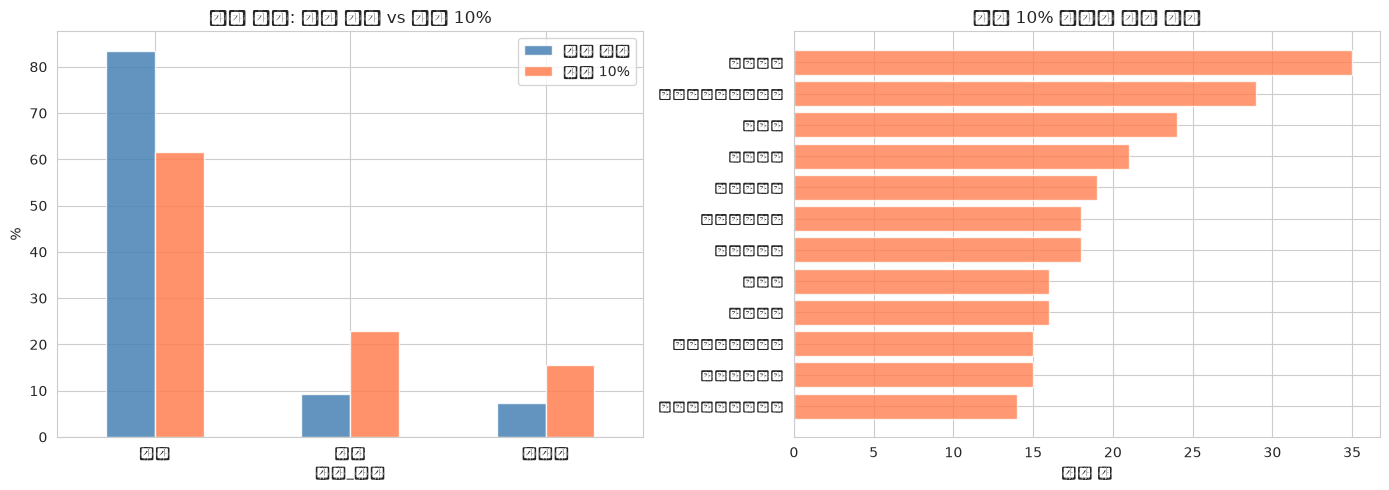

In [18]:
p90 = df_m[CREDIT].quantile(.90)
df_m['tier'] = pd.cut(
    df_m[CREDIT].fillna(0),
    bins=[-1, 0, df_m[CREDIT].quantile(.5), p90, float('inf')],
    labels=['미사용','하위 50%','중간 40%','상위 10%']
)

heavy    = df_m[df_m['tier'] == '상위 10%']
all_act  = df_m[df_m[CREDIT] > 0]
print(f"상위 10% 기준 크레딧: {p90:,.0f} 이상  |  유저 수: {len(heavy):,}명")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 신분 구성 비교
id_all   = all_act['신분_정제'].value_counts(normalize=True) * 100
id_heavy = heavy['신분_정제'].value_counts(normalize=True) * 100
pd.DataFrame({'전체 활성':id_all,'상위 10%':id_heavy}).fillna(0).plot(
    kind='bar', ax=axes[0], color=['steelblue','coral'], edgecolor='white', alpha=.85)
axes[0].set_title('신분 구성: 전체 활성 vs 상위 10%')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylabel('%')
axes[0].legend()

# 상위 10% 소속 분포
top_dept = heavy['소속'].value_counts().head(12)
axes[1].barh(range(len(top_dept)), top_dept.values, color='coral', alpha=.8)
axes[1].set_yticks(range(len(top_dept)))
axes[1].set_yticklabels(top_dept.index, fontsize=8.5)
axes[1].invert_yaxis()
axes[1].set_xlabel('유저 수')
axes[1].set_title('상위 10% 유저의 소속 분포')

plt.tight_layout()
plt.savefig('04d_heavy.png', dpi=150, bbox_inches='tight')
plt.show()


### 4-5. 미사용 유저 특성 (크레딧 = 0)

미사용 유저: 1,466명 (17.8%)


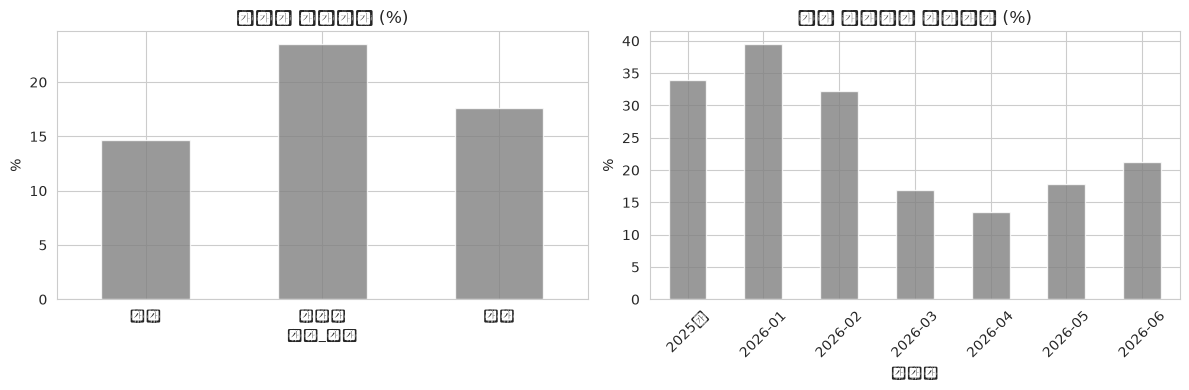

In [19]:
zero = df_m[df_m[CREDIT] == 0]
print(f"미사용 유저: {len(zero):,}명 ({len(zero)/len(df_m)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 신분별 미사용율
zr_id = (df_m.groupby('신분_정제')
         .apply(lambda x: (x[CREDIT]==0).sum() / len(x) * 100)
         .round(1))
zr_id.plot(kind='bar', ax=axes[0], color='gray', edgecolor='white', alpha=.8)
axes[0].set_title('신분별 미사용율 (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylabel('%')

# 코호트별 미사용율
zr_c = (df_m.groupby('코호트')
        .apply(lambda x: (x[CREDIT]==0).sum() / len(x) * 100)
        .reindex(cohort_order).dropna().round(1))
zr_c.plot(kind='bar', ax=axes[1], color='gray', edgecolor='white', alpha=.8)
axes[1].set_title('가입 코호트별 미사용율 (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('%')

plt.tight_layout()
plt.savefig('04e_zero.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. 모델 사용 분석

In [20]:
# 모델별 총 크레딧 & 사용 유저 수
model_stats = {}
for m in MODELS:
    mc = model_credit_sum(df, m)
    if mc.sum() > 0:
        model_stats[m] = {'총_크레딧': mc.sum(), '사용_유저수': (mc > 0).sum()}

mu = pd.DataFrame(model_stats).T.sort_values('총_크레딧', ascending=False)
mu['비중(%)'] = (mu['총_크레딧'] / mu['총_크레딧'].sum() * 100).round(2)
print("=== 모델별 크레딧 사용 TOP 15 ===")
print(mu.head(15).round(1).to_string())


=== 모델별 크레딧 사용 TOP 15 ===
                         총_크레딧  사용_유저수  비중(%)
Claude 4.6 Sonnet    4805664.5  1901.0   24.2
GPT-5.3 Chat         4341525.8  4236.0   21.8
Gemini 3.1 Pro       2881882.5  1794.0   14.5
Claude 4.7 Opus      2570201.6   848.0   12.9
Claude 4.6 Opus      1625318.0   585.0    8.2
Claude 4.8 Opus      1192665.9   481.0    6.0
Claude 4.5 Opus       602991.8   286.0    3.0
GPT-5.1 Chat          389003.3   457.0    2.0
Claude 4.5 Sonnet     309023.4   215.0    1.6
Claude 4.5 Haiku      163492.2   301.0    0.8
Gemini 3.5 Flash      146194.4   278.0    0.7
Sonar Pro             136564.5   289.0    0.7
Claude Fable 5        132481.7    67.0    0.7
GPT-5 Thinking        106730.9   212.0    0.5
Sonar Reasoning Pro    88577.8   202.0    0.4


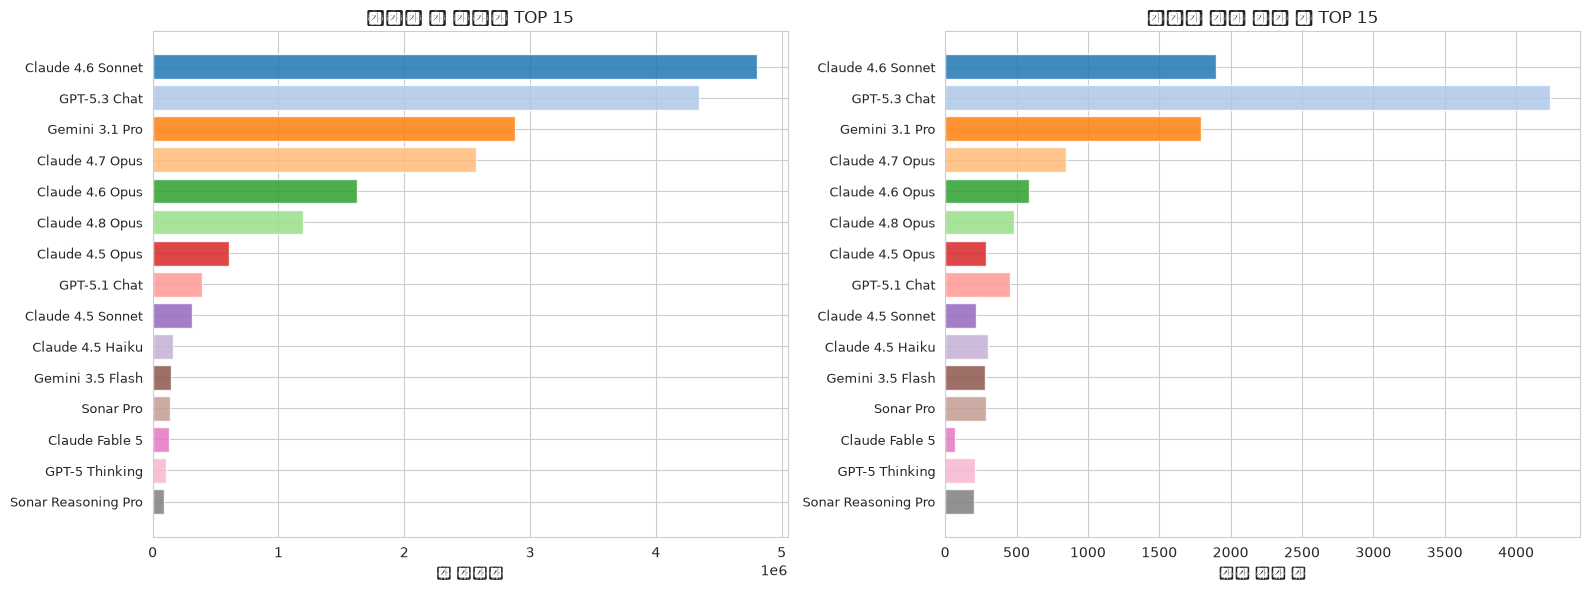

In [21]:
top15 = mu.head(15)
colors = list(plt.cm.tab20.colors[:15])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(range(len(top15)), top15['총_크레딧'], color=colors, alpha=.85)
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(top15.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('총 크레딧')
axes[0].set_title('모델별 총 크레딧 TOP 15')

axes[1].barh(range(len(top15)), top15['사용_유저수'], color=colors, alpha=.85)
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels(top15.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('사용 유저 수')
axes[1].set_title('모델별 사용 유저 수 TOP 15')

plt.tight_layout()
plt.savefig('05a_model_rank.png', dpi=150, bbox_inches='tight')
plt.show()


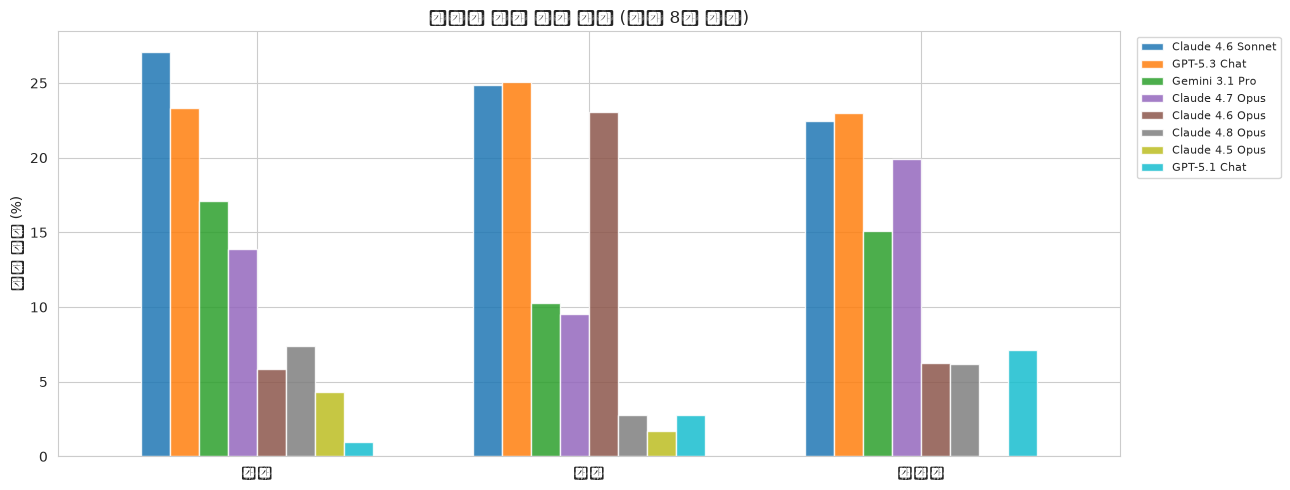

In [22]:
# 신분별 모델 선호도 (상위 8개 모델)
top8 = mu.head(8).index.tolist()

by_id = {}
for 신분 in ['학생','교수','교직원']:
    sub = df_m[df_m['신분_정제'] == 신분]
    by_id[신분] = {m: model_credit_sum(sub, m).sum() for m in top8}

mi_df  = pd.DataFrame(by_id).T
mi_pct = mi_df.div(mi_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
mi_pct.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', alpha=.85, width=.7)
ax.set_title('신분별 모델 사용 비중 (상위 8개 모델)', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.set_ylabel('사용 비중 (%)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('05b_model_identity.png', dpi=150, bbox_inches='tight')
plt.show()


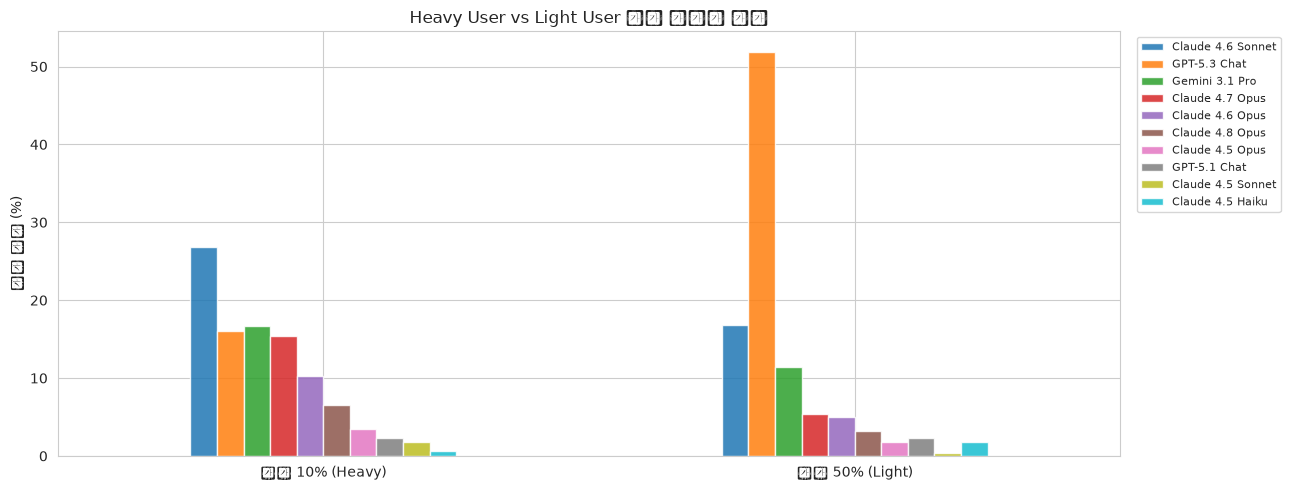

In [23]:
# Heavy vs Light 모델 비교
top10 = mu.head(10).index.tolist()
heavy_u = df_m[df_m['tier'] == '상위 10%']
light_u = df_m[df_m['tier'] == '하위 50%']

hm = {m: model_credit_sum(heavy_u, m).sum() for m in top10}
lm = {m: model_credit_sum(light_u, m).sum() for m in top10}
cmp = pd.DataFrame({'상위 10% (Heavy)': hm, '하위 50% (Light)': lm})
cmp_pct = cmp.div(cmp.sum(axis=0), axis=1) * 100

cmp_pct.T.plot(kind='bar', figsize=(13, 5), colormap='tab10', edgecolor='white', alpha=.85)
plt.title('Heavy User vs Light User 모델 선호도 비교', fontsize=12)
plt.xticks(rotation=0)
plt.ylabel('사용 비중 (%)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('05c_model_heavy_light.png', dpi=150, bbox_inches='tight')
plt.show()


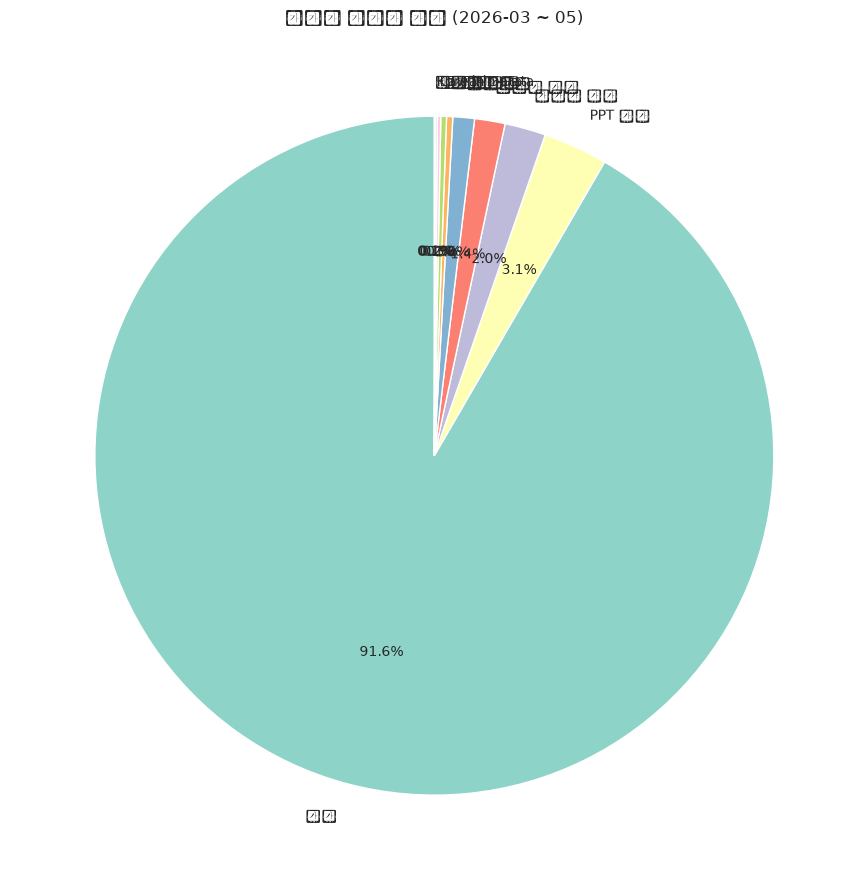

기능별:
  채팅:    4,065,652  (91.6%)
  PPT 생성:      136,052  (3.1%)
  이미지 생성:       86,521  (2.0%)
  비디오 생성:       64,309  (1.4%)
  에이전트:       45,491  (1.0%)
  딥 리서치:       13,075  (0.3%)
  웹검색:       11,961  (0.3%)
  Law in Data:        7,163  (0.2%)
  Korea-in-Data:        4,039  (0.1%)
  오디오:        2,345  (0.1%)


In [24]:
# 기능별 크레딧 비중  (utf-8-sig → BOM 자동 처리, 빈 첫줄 스킵)
with open(f'{DATA_DIR}/usage_data_deidentified/'
          'usage_export_2026-03-01_to_2026-05-31_20260616_022658.csv',
          encoding='utf-8-sig') as f:
    lines_raw = [l.rstrip() for l in f if l.strip()]  # 빈줄 제거
header = lines_raw[0].split(',')
vals   = lines_raw[1].split(',')

feat = {}
for k, v in zip(header, vals):
    try:
        fv = float(v)
        if k != '합계' and fv > 0:
            feat[k] = fv
    except Exception:
        pass
feat_s   = pd.Series(feat, dtype='float64').sort_values(ascending=False)
feat_arr = np.array(list(feat_s), dtype=np.float64)

fig, ax = plt.subplots(figsize=(9, 9))
n = len(feat_arr)
pal = (list(plt.cm.Set3.colors) * ((n // 12) + 2))[:n]
wedges, texts, autotexts = ax.pie(
    feat_arr, labels=feat_s.index, autopct='%1.1f%%',
    colors=pal, startangle=90)
ax.set_title('기능별 크레딧 비중 (2026-03 ~ 05)', fontsize=12)
plt.tight_layout()
plt.savefig('05d_feature.png', dpi=150, bbox_inches='tight')
plt.show()

print("기능별:")
for k, v in feat_s.items():
    print(f"  {k}: {v:>12,.0f}  ({v/feat_s.sum()*100:.1f}%)")


## 6. 유료 결제 전환 분석

In [25]:
df_m['유료전환'] = df_m['개인 구매 크레딧'].fillna(0) > 0
paid = df_m['유료전환']
print(f"유료 전환 유저: {paid.sum():,}명  ({paid.mean()*100:.2f}%)")
print(f"유료 유저 평균 개인 구매 크레딧: "
      f"{df_m[paid]['개인 구매 크레딧'].mean():,.0f}")
print()

# 신분별
by_id = df_m.groupby('신분_정제')['유료전환'].agg(유저수='count', 전환수='sum', 전환율='mean')
by_id['전환율(%)'] = (by_id['전환율'] * 100).round(2)
print("신분별 전환율:")
print(by_id.to_string())


유료 전환 유저: 1,070명  (12.99%)
유료 유저 평균 개인 구매 크레딧: 6,170

신분별 전환율:
        유저수  전환수       전환율  전환율(%)
신분_정제                             
교수      729   71  0.097394    9.74
교직원     648   25  0.038580    3.86
학생     6861  974  0.141962   14.20


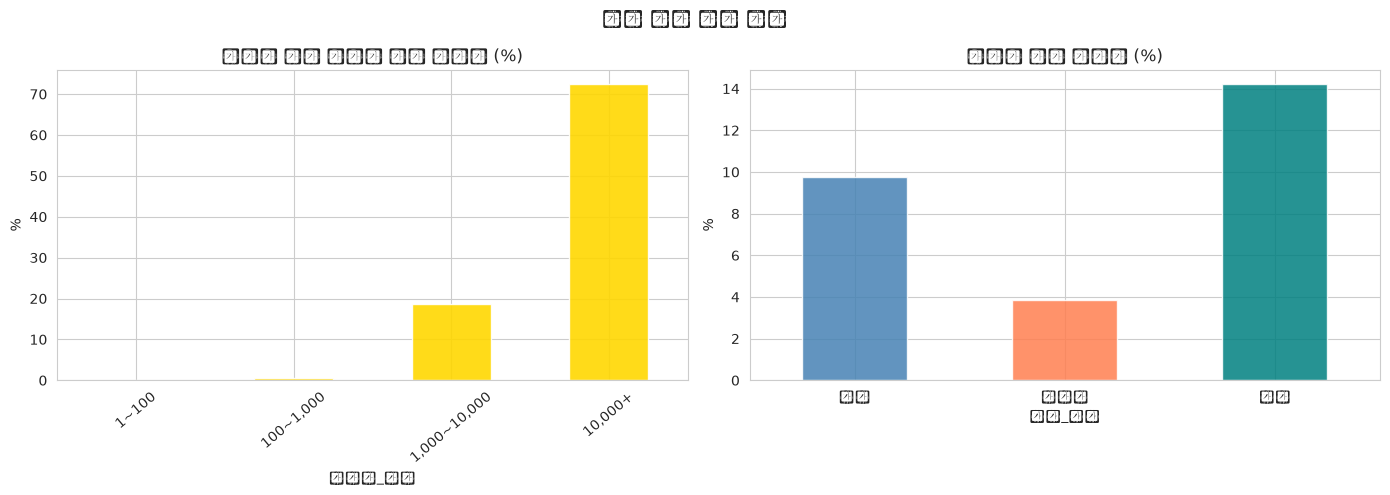


크레딧 구간별 전환율:
               유저수  전환수  전환율(%)
크레딧_구간                         
1~100         2453    4    0.16
100~1,000     1425    8    0.56
1,000~10,000  3897  723   18.55
10,000+        463  335   72.35


In [26]:
df_m['크레딧_구간'] = pd.cut(
    df_m[CREDIT].fillna(0),
    bins=[-1, 0, 100, 1_000, 10_000, float('inf')],
    labels=['0 (미사용)','1~100','100~1,000','1,000~10,000','10,000+'],
    right=False
)

by_bkt = df_m.groupby('크레딧_구간')['유료전환'].agg(유저수='count', 전환수='sum')
by_bkt['전환율(%)'] = (by_bkt['전환수'] / by_bkt['유저수'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_bkt['전환율(%)'].plot(kind='bar', ax=axes[0],
    color='gold', edgecolor='white', alpha=.9)
axes[0].set_title('크레딧 사용 구간별 유료 전환율 (%)')
axes[0].tick_params(axis='x', rotation=40)
axes[0].set_ylabel('%')

by_id['전환율(%)'].plot(kind='bar', ax=axes[1],
    color=['steelblue','coral','teal'][:len(by_id)], edgecolor='white', alpha=.85)
axes[1].set_title('신분별 유료 전환율 (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylabel('%')

plt.suptitle('유료 결제 전환 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_paid.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n크레딧 구간별 전환율:")
print(by_bkt.to_string())


---
## 분석 요약

| 섹션 | 주요 확인 사항 |
|------|--------------|
| **1. 분포** | 전체 분포 히스토그램(linear/log), 통계 테이블(mean/median/mode/max/min/P10~P99), Pareto 분석, 소진율 분포 |
| **2. 시계열** | DAU/방문자/크레딧 일별 추이, 7일 이동평균, 요일 패턴 |
| **3. 코호트** | 가입월별 활성화율·크레딧 분포 비교 |
| **4. 세그먼트** | 신분별·소속별·직급별·Heavy user 프로필·미사용자 특성 |
| **5. 모델** | 모델별 크레딧/유저 수 랭킹, 신분별·Heavy/Light 유저별 선호도 |
| **6. 전환** | 유료 전환율 전체 + 신분별/크레딧 구간별 분해 |
